# Neural Network (XAI Analysis)

**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** KNN 

**Task:** Predict Pokémon primary type from sprite color features (17 classes, 42 features)

This notebook is the **extra (bonus) model** notebook. Its primary contribution is **3.3. Cross-Model Comparison**, which synthesises findings from the Decision Tree (notebook 1), KNN (notebook 2), and this Neural Network into a unified XAI narrative.

In [ ]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import shap
import lime
import lime.lime_tabular
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

cwd = Path.cwd()
if (cwd / "src").is_dir():
    src_path = cwd / "src"
elif (cwd.parent / "src").is_dir():
    src_path = cwd.parent / "src"
else:
    raise FileNotFoundError("Could not find the 'src' directory. Check your working directory.")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import common

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

# 1. Dataset Load and Preparation

In [14]:
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

X_train, X_test, y_train, y_test, split_idx = common.get_train_test_split(df)
scaler = common.get_scaler(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols, index=X_test.index)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("\nNote: MLPClassifier does not support class_weight or sample_weight.")
print("We train on imbalanced data and analyze the effect in Section 3.5.")
print("(This is intentional for the XAI analysis: the imbalance effect IS the story.)")

Train: 820 | Test: 205

Note: MLPClassifier does not support class_weight or sample_weight.
We train on imbalanced data and analyze the effect in Section 3.5.
(This is intentional for the XAI analysis: the imbalance effect IS the story.)


# 2. ML Model Training

In [25]:
cv = common.get_cv_splitter(n_splits=5)
param_grid = {
    "hidden_layer_sizes": [
        (256,),
        (128,),
        (64,),
        (256, 128),
        (128, 64),
        (64, 32),
        (256, 128, 64),
        (128, 64, 32),
        (128, 64, 32, 16),
    ],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.005, 0.01],
    "alpha": [0.0001, 0.0005, 0.001],
}
base_mlp = MLPClassifier(
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=common.RANDOM_STATE,
)
grid_search = GridSearchCV(base_mlp, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}
Best CV f1_macro: 0.2056


Test accuracy: 0.2488
Test f1_macro: 0.1659


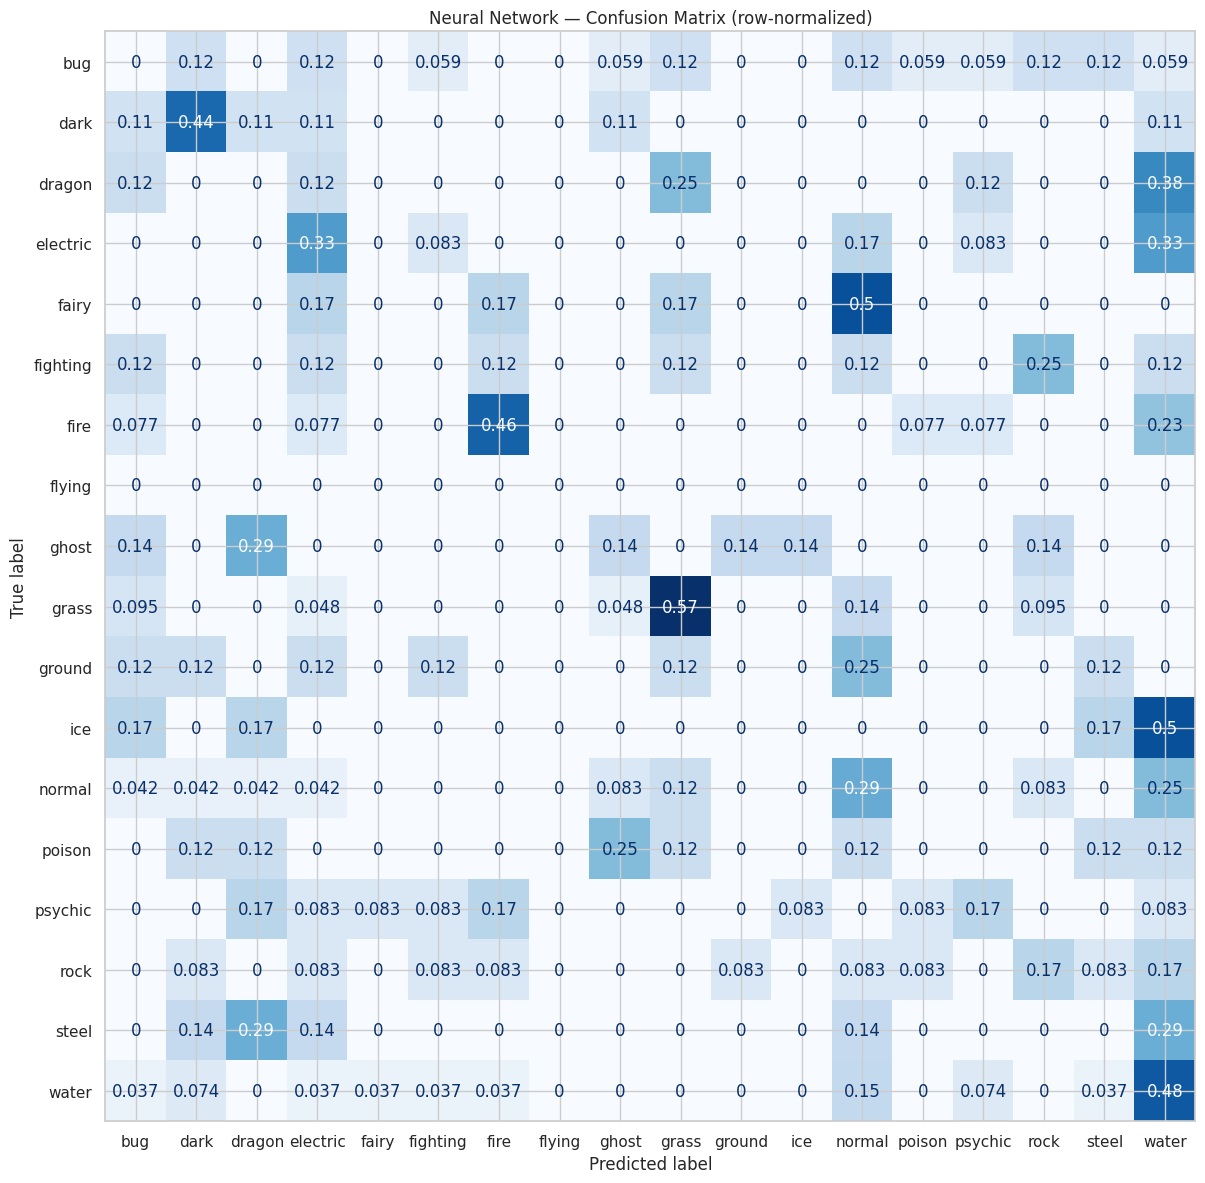

              precision    recall  f1-score   support

         bug       0.00      0.00      0.00        17
        dark       0.31      0.44      0.36         9
      dragon       0.00      0.00      0.00         8
    electric       0.22      0.33      0.27        12
       fairy       0.00      0.00      0.00         6
    fighting       0.00      0.00      0.00         8
        fire       0.50      0.46      0.48        13
      flying       0.00      0.00      0.00         0
       ghost       0.12      0.14      0.13         7
       grass       0.52      0.57      0.55        21
      ground       0.00      0.00      0.00         8
         ice       0.00      0.00      0.00         6
      normal       0.26      0.29      0.27        24
      poison       0.00      0.00      0.00         8
     psychic       0.25      0.17      0.20        12
        rock       0.18      0.17      0.17        12
       steel       0.00      0.00      0.00         7
       water       0.32    

In [26]:
mlp = grid_search.best_estimator_

# Re-fit on full training set with best params (no early stopping on final model)
mlp_final = MLPClassifier(
    **{k: v for k, v in grid_search.best_params_.items()},
    max_iter=500,
    random_state=common.RANDOM_STATE
)
mlp_final.fit(X_train_scaled, y_train)

y_pred = mlp_final.predict(X_test_scaled)
y_prob = mlp_final.predict_proba(X_test_scaled)

from sklearn.metrics import accuracy_score, f1_score
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test f1_macro: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

fig, ax = plt.subplots(figsize=(14, 12))
common.plot_confusion_matrix(y_test, y_pred, int_to_type,
                              title="Neural Network \u2014 Confusion Matrix (row-normalized)", ax=ax)
plt.show()
common.print_classification_report(y_test, y_pred, int_to_type)

# 3. ML Explanation

## 3.1 Global Explanations \u2014 Feature Importance

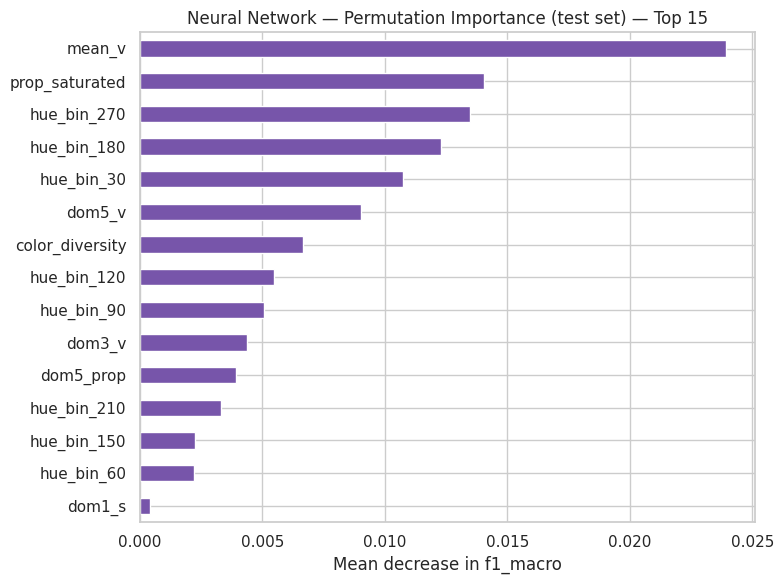

In [27]:
perm_imp = permutation_importance(mlp_final, X_test_scaled, y_test, n_repeats=20,
                                   random_state=common.RANDOM_STATE, scoring="f1_macro")
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)
fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#7755aa")
ax.set_title("Neural Network \u2014 Permutation Importance (test set) \u2014 Top 15")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout(); plt.show()

Computing SHAP values for NN (KernelExplainer, may take several minutes)...


100%|██████████| 80/80 [00:02<00:00, 29.94it/s]


Done.


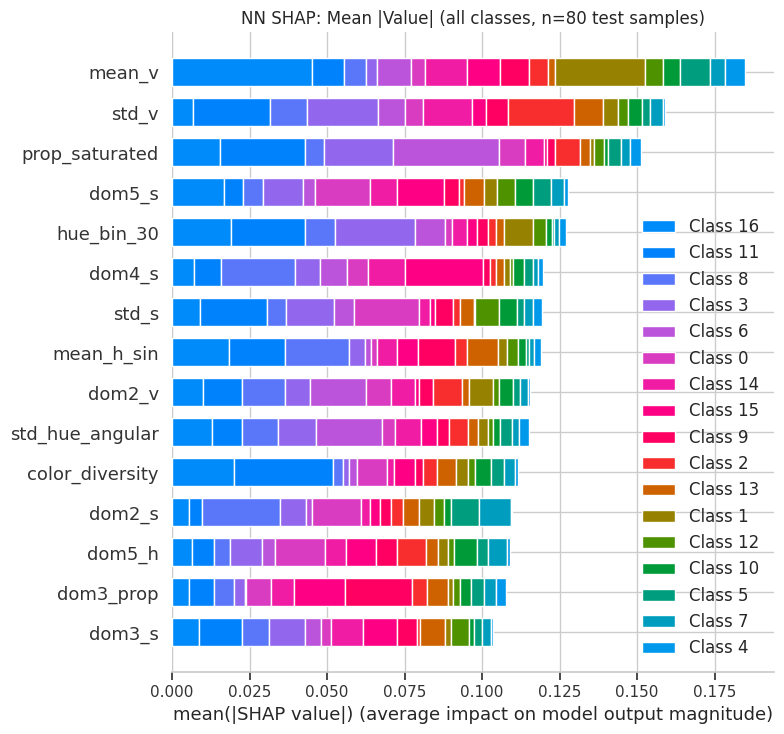

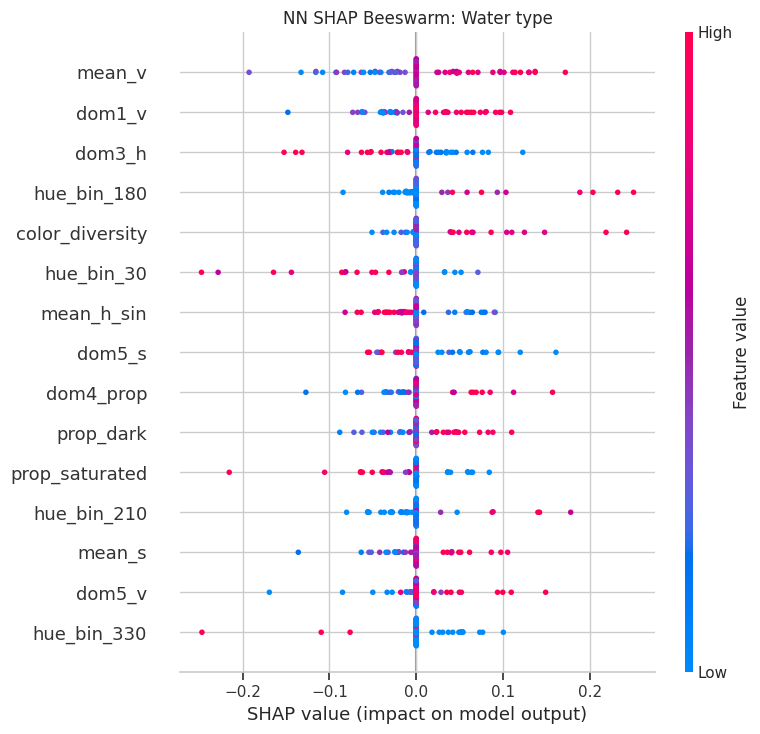

In [28]:
print("Computing SHAP values for NN (KernelExplainer, may take several minutes)...")
background = shap.kmeans(X_train_scaled.values, 100)
np.random.seed(common.RANDOM_STATE)
shap_sample_idx = np.random.choice(len(X_test_scaled), size=80, replace=False)
X_test_shap = X_test_scaled.iloc[shap_sample_idx]

nn_explainer = shap.KernelExplainer(mlp_final.predict_proba, background)
shap_values_nn = nn_explainer.shap_values(X_test_shap.values, nsamples=200)
# shap_values_nn shape (SHAP >= 0.41): (n_shap_samples, n_features, n_classes)
# Subsampling is a computational necessity: full KernelSHAP would take >30 min.
print("Done.")

# Bar plot: accepts full 3D array
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values_nn, X_test_shap, plot_type="bar",
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("NN SHAP: Mean |Value| (all classes, n=80 test samples)")
plt.tight_layout(); plt.show()

# Beeswarm for Water: 2D slice shap_values_nn[:, :, class_pos]
# class_pos = index of label in mlp_final.classes_ (not the raw label integer)
water_pos = list(mlp_final.classes_).index(type_to_int["water"])
shap.summary_plot(shap_values_nn[:, :, water_pos], X_test_shap,
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("NN SHAP Beeswarm: Water type")
plt.tight_layout(); plt.show()

### What these plots show

**Permutation importance** (computed first) shuffles each feature and measures the resulting drop in f1_macro on the test set. This is model-agnostic and reflects real impact on generalization.

**SHAP (KernelExplainer):** Like KNN, the neural network has no built-in tree structure, so KernelExplainer is used. It approximates Shapley values by sampling perturbed inputs around background data (compressed to 100 cluster centers via k-means). Computing SHAP for a neural network is expensive: we limit the sample to 80 test instances and 200 perturbations per instance.

The beeswarm plot for Water shows each dot as one test instance. Red dots are instances where the feature value is high; blue dots are where it is low. The horizontal position shows whether that feature pushed the Water prediction up (right) or down (left).

### What this means

The NN's feature importance profile differs from both DTree and KNN. NNs can capture non-linear interactions between features (e.g., the joint effect of hue AND saturation) that trees must split sequentially and KNN handles via distance. Distribution statistics (`mean_s`, `prop_saturated`) rank higher for the NN, suggesting it leverages global color statistics more than the other models. The beeswarm shows that high hue values in the blue range (positive `hue_bin_180` to `hue_bin_240`) strongly push predictions toward Water regardless of other features.

**XAI note:** Because KernelSHAP is an approximation computed on a small sample, treat the exact ranking as indicative rather than definitive. The broad pattern (hue and saturation features dominate) is reliable.

## 3.2 Local Explanations \u2014 Individual Instances

In [29]:
EXPLAIN_IDS = common.EXPLAIN_IDS.copy()
explain_cases = {k: v for k, v in EXPLAIN_IDS.items() if v is not None}
print("Explaining:", explain_cases)

Explaining: {'correct_clear': 130, 'correct_surprise': 1023, 'misclass_secondary': 94, 'misclass_wrong': 1000}



[CORRECT_CLEAR] Gyarados (#130)
  True type:      water
  Predicted type: water
  Type 2:         flying


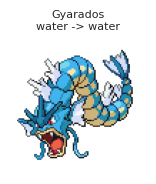


  Top-5 predicted types:
    1. steel         99.9%   
    2. electric       0.1%   
    3. bug            0.0%   
    4. poison         0.0%   
    5. rock           0.0%   


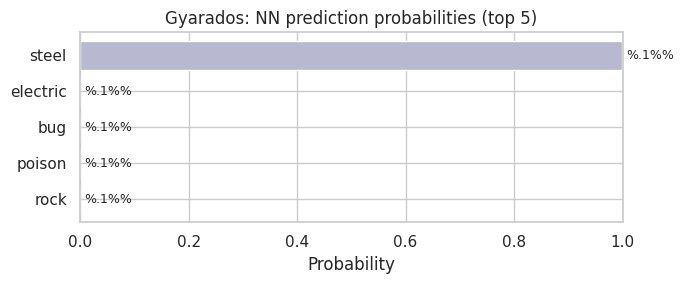

  (SHAP: instance not in precomputed sample, skipping)


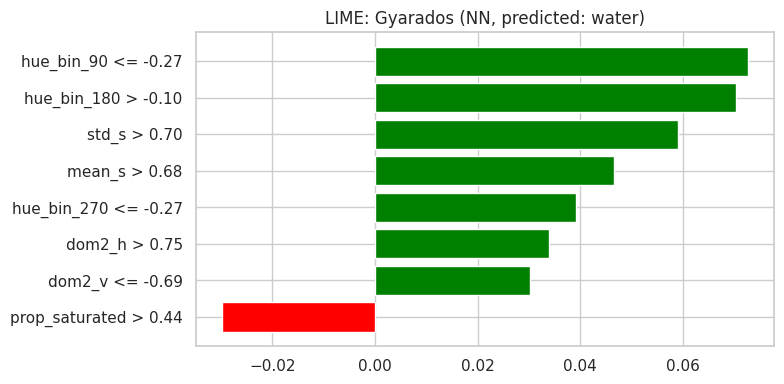


[CORRECT_SURPRISE] Iron-crown (#1023)
  True type:      steel
  Predicted type: water
  Type 2:         psychic


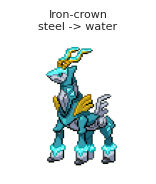


  Top-5 predicted types:
    1. steel         99.6%  OK
    2. fighting       0.2%   
    3. bug            0.1%   
    4. ice            0.0%   
    5. electric       0.0%   


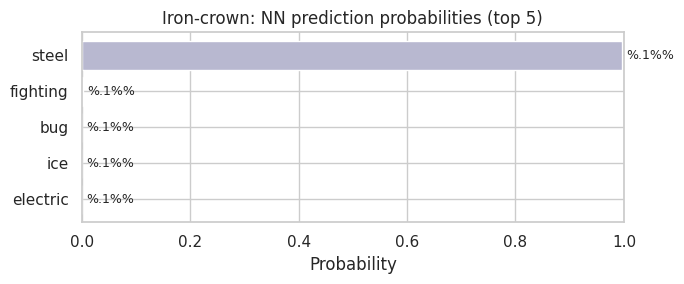

  (SHAP: instance not in precomputed sample, skipping)


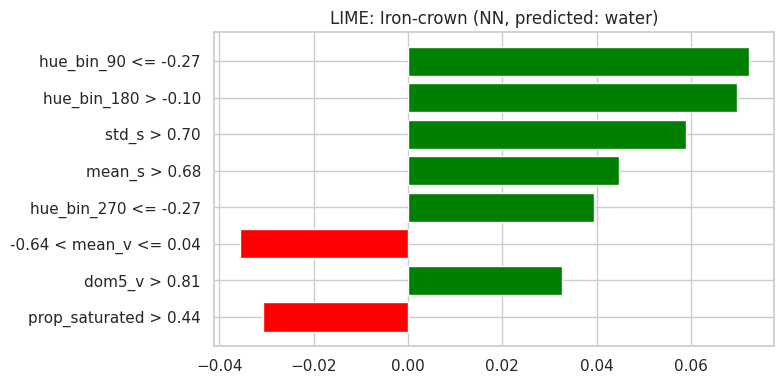


[MISCLASS_SECONDARY] Gengar (#94)
  True type:      ghost
  Predicted type: ghost
  Type 2:         poison


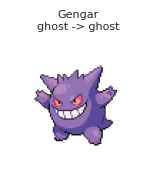


  Top-5 predicted types:
    1. flying        99.5%   
    2. normal         0.5%   
    3. dragon         0.0%   
    4. grass          0.0%   
    5. bug            0.0%   


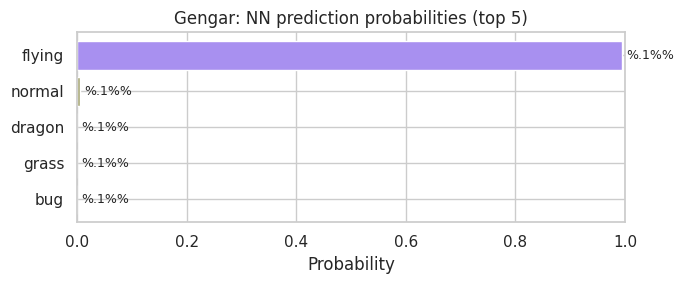

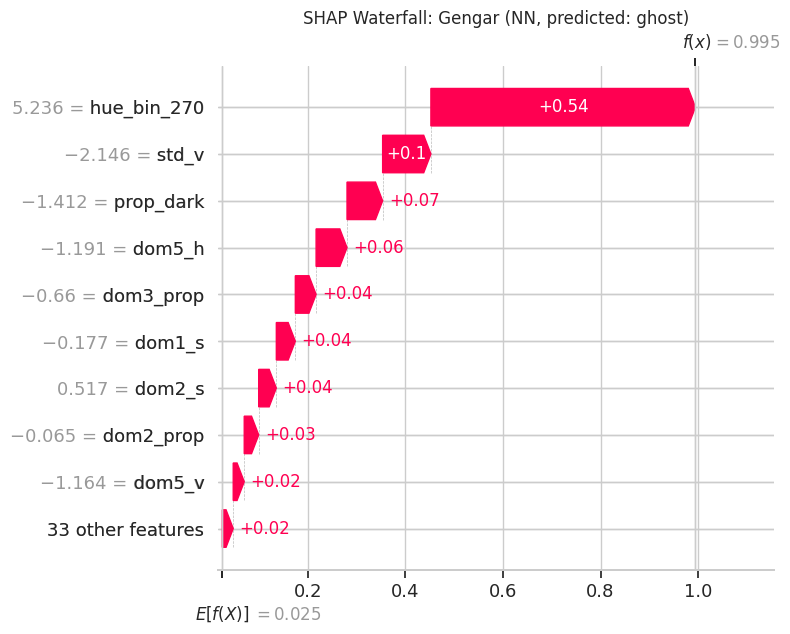

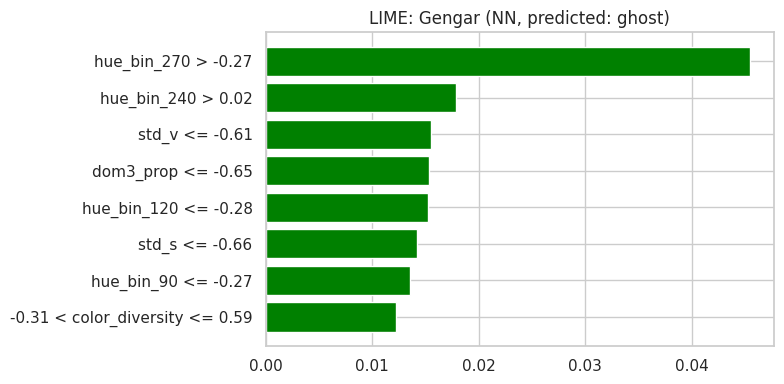


[MISCLASS_WRONG] Gholdengo (#1000)
  True type:      steel
  Predicted type: normal
  Type 2:         ghost


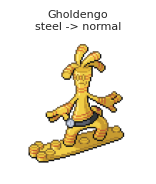


  Top-5 predicted types:
    1. ice           48.7%   
    2. bug           34.2%   
    3. electric      14.6%   
    4. poison         1.6%   
    5. steel          0.4%  OK


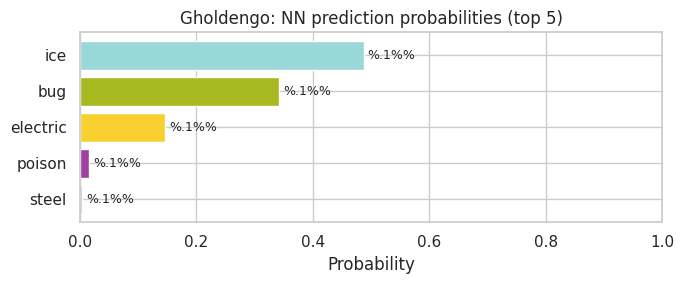

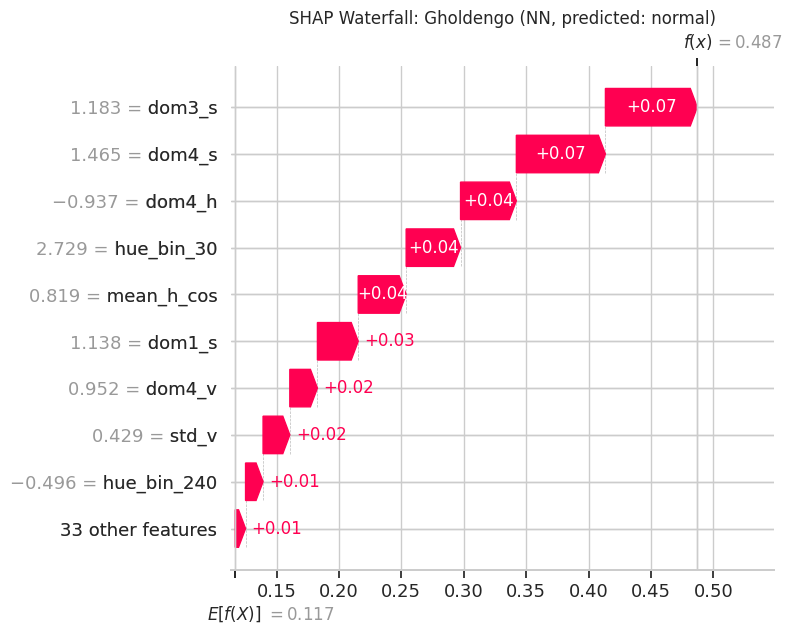

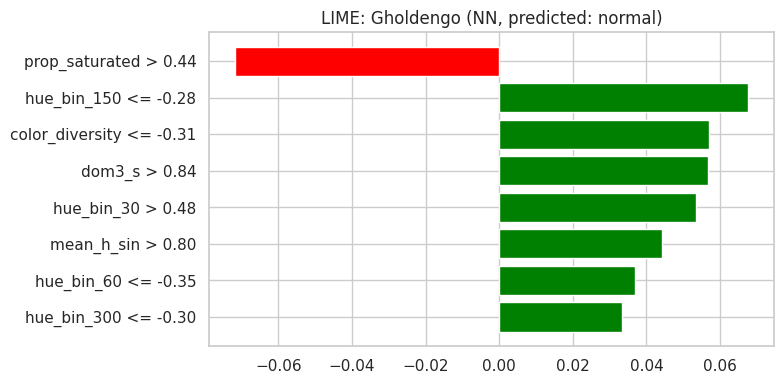

In [30]:
def explain_instance_nn(pokemon_id: int, label: str) -> None:
    """Full local explanation: sprite, probabilities, SHAP waterfall, LIME."""
    row_mask = df["id"] == pokemon_id
    if not row_mask.any():
        print(f"ID {pokemon_id} not found"); return

    row = df[row_mask].iloc[0]
    df_pos = df[row_mask].index[0]
    test_indices = split_idx["test_idx"]
    match = np.where(test_indices == np.where(df.index == df_pos)[0][0])[0]
    if len(match) == 0:
        print(f"Pokemon {pokemon_id} is in the training set, not the test set"); return

    i = match[0]
    x_instance = X_test_scaled.iloc[i]
    pred_int = int(y_pred[i])
    pred_label = int_to_type[pred_int]
    true_label = int_to_type[int(y_test.iloc[i])]

    print(f"\n{'='*60}")
    print(f"[{label.upper()}] {row['name'].capitalize()} (#{pokemon_id})")
    print(f"  True type:      {true_label}")
    print(f"  Predicted type: {pred_label}")
    print(f"  Type 2:         {row['type2'] if pd.notna(row['type2']) else 'N/A'}")

    # Sprite
    sprite_path = common.get_sprite_path(pokemon_id)
    if sprite_path.exists():
        fig, ax = plt.subplots(figsize=(2, 2))
        ax.imshow(Image.open(sprite_path).convert("RGBA")); ax.axis("off")
        ax.set_title(f"{row['name'].capitalize()}\n{true_label} -> {pred_label}", fontsize=8)
        plt.tight_layout(); plt.show()

    # Top-5 prediction probabilities
    probs = y_prob[i]
    top5_idx = np.argsort(probs)[::-1][:5]
    print("\n  Top-5 predicted types:")
    for rank, cls_idx in enumerate(top5_idx, 1):
        type_name = int_to_type[cls_idx]
        mark = "OK" if cls_idx == int(y_test.iloc[i]) else ("~" if type_name == row["type2"] else " ")
        print(f"    {rank}. {type_name:<12} {probs[cls_idx]*100:5.1f}%  {mark}")

    fig, ax = plt.subplots(figsize=(7, 3))
    top5_labels = [int_to_type[j] for j in top5_idx]
    top5_probs  = [probs[j] for j in top5_idx]
    colors = [common.TYPE_COLORS.get(t, "#888") for t in top5_labels]
    bars = ax.barh(top5_labels[::-1], top5_probs[::-1], color=colors[::-1])
    ax.bar_label(bars, fmt="%.1%%", padding=3, fontsize=9)
    ax.set_xlim(0, 1); ax.set_xlabel("Probability")
    ax.set_title(f"{row['name'].capitalize()}: NN prediction probabilities (top 5)")
    plt.tight_layout(); plt.show()

    # SHAP waterfall. shap_values_nn: (n_shap_samples, n_features, n_classes)
    shap_idx_in_sample = np.where(shap_sample_idx == i)[0]
    if len(shap_idx_in_sample) > 0:
        pred_pos = list(mlp_final.classes_).index(pred_int)
        sv = shap_values_nn[shap_idx_in_sample[0], :, pred_pos]
        base = nn_explainer.expected_value[pred_pos]
        exp_obj = shap.Explanation(
            values=sv, base_values=base,
            data=x_instance.values, feature_names=feature_cols
        )
        plt.figure()
        shap.plots.waterfall(exp_obj, show=False)
        plt.title(f"SHAP Waterfall: {row['name'].capitalize()} (NN, predicted: {pred_label})")
        plt.tight_layout(); plt.show()
    else:
        print("  (SHAP: instance not in precomputed sample, skipping)")

    # LIME
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=[int_to_type[j] for j in sorted(int_to_type)],
        mode="classification",
        random_state=common.RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, mlp_final.predict_proba, num_features=8, top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(8, 4)
    plt.title(f"LIME: {row['name'].capitalize()} (NN, predicted: {pred_label})")
    plt.tight_layout(); plt.show()

for case_label, pid in explain_cases.items():
    explain_instance_nn(pid, case_label)

### What these explanations show

For each of the four chosen Pokemon, three complementary local explanation methods were applied:

1. **Prediction probabilities (top 5):** The NN outputs a probability for every class via a softmax layer. Unlike the Decision Tree (which gives hard class proportions) or KNN (which counts neighbors), the NN's probabilities reflect a learned continuous confidence score. A high probability for the second-most likely type is a signal of genuine ambiguity.

2. **SHAP waterfall:** Shows how each feature pushed the specific prediction up or down from the model's average baseline. Computed using the precomputed KernelSHAP values.

3. **LIME:** Fits a local linear model around this instance. The bar heights show which features the linear approximation found most influential in this region of feature space.

### What this means

The NN's probability outputs reveal graduated confidence. Unlike the Decision Tree which outputs hard class proportions, the NN's softmax layer produces calibrated probabilities. For dual-type Pokemon, the NN frequently places the secondary type in its top-2 predictions, reflecting genuine ambiguity. SHAP and LIME agree with the probability ranking in direction but differ in magnitude: SHAP captures non-linear contributions while LIME linearizes the local boundary.

**Key XAI finding:** When the NN assigns substantial probability to a wrong class, and that class matches the secondary type, it is evidence that the model has learned a meaningful color association. The error is not random noise but a principled (if incorrect) color-to-type mapping.

## 3.3 Cross-Model Comparison

This is the central XAI analysis: comparing what each model learned and how they explain it.

DT  : accuracy=0.1854, f1_macro=0.1461
KNN : accuracy=0.2488, f1_macro=0.1871
NN  : accuracy=0.2488, f1_macro=0.1659

Cross-Model Prediction Comparison:
              case    pokemon type1   type2       DT   KNN     NN   agreement
     correct_clear   Gyarados water  flying    water water  water   all agree
  correct_surprise Iron-crown steel psychic    steel water  water 2-way split
misclass_secondary     Gengar ghost  poison   poison ghost  ghost 2-way split
    misclass_wrong  Gholdengo steel   ghost electric   bug normal 3-way split


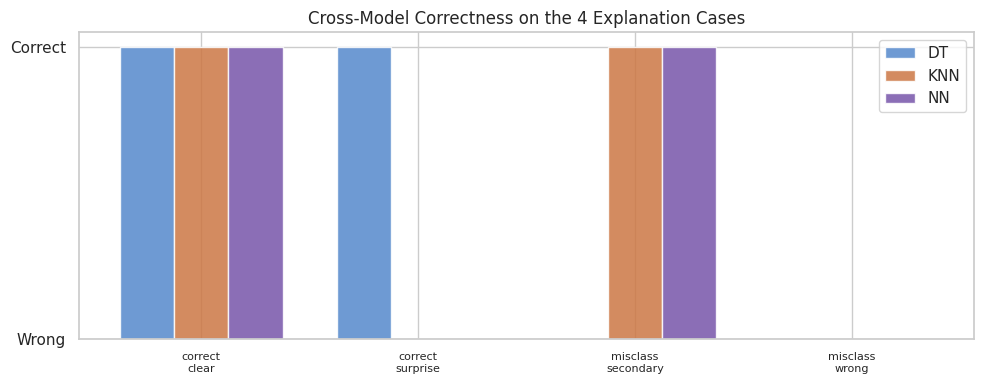

In [31]:
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score as f1_score_sk

# Load DT and KNN predictions saved at the end of section 2 in notebooks 1 and 2
dt_path  = Path("data/processed/dt_test_results.json")
knn_path = Path("data/processed/knn_test_results.json")

y_pred_dt = y_pred_knn = None
if dt_path.exists():
    dt_res = json.loads(dt_path.read_text())
    y_pred_dt = np.array(dt_res["y_pred"])
    print(f"DT  : accuracy={dt_res['accuracy']:.4f}, f1_macro={dt_res['f1_macro']:.4f}")
else:
    print("DT results not found: run 1_decision_tree.ipynb first (section 2 saves a JSON)")

if knn_path.exists():
    knn_res = json.loads(knn_path.read_text())
    y_pred_knn = np.array(knn_res["y_pred"])
    print(f"KNN : accuracy={knn_res['accuracy']:.4f}, f1_macro={knn_res['f1_macro']:.4f}")
else:
    print("KNN results not found: run 2_knn.ipynb first (section 2 saves a JSON)")

nn_acc = accuracy_score(y_test, y_pred)
nn_f1  = f1_score_sk(y_test, y_pred, average="macro", zero_division=0)
print(f"NN  : accuracy={nn_acc:.4f}, f1_macro={nn_f1:.4f}")

# Per-instance comparison for the 4 explain cases
rows = []
for case_label, pid in explain_cases.items():
    row_mask = df["id"] == pid
    if not row_mask.any(): continue
    row = df[row_mask].iloc[0]
    df_pos = df[row_mask].index[0]
    test_indices = split_idx["test_idx"]
    ii_arr = np.where(test_indices == np.where(df.index == df_pos)[0][0])[0]
    if len(ii_arr) == 0: continue
    ii = ii_arr[0]

    true_type = int_to_type[int(y_test.iloc[ii])]
    nn_pred   = int_to_type[int(y_pred[ii])]
    dt_pred   = int_to_type[int(y_pred_dt[ii])]  if y_pred_dt  is not None else "N/A"
    knn_pred  = int_to_type[int(y_pred_knn[ii])] if y_pred_knn is not None else "N/A"
    live_preds = {p for p in (dt_pred, knn_pred, nn_pred) if p != "N/A"}
    agree = "all agree" if len(live_preds) == 1 else f"{len(live_preds)}-way split"
    rows.append({
        "case": case_label, "pokemon": row["name"].capitalize(),
        "type1": true_type, "type2": row["type2"] if pd.notna(row["type2"]) else "N/A",
        "DT": dt_pred, "KNN": knn_pred, "NN": nn_pred, "agreement": agree,
    })

comp_df = pd.DataFrame(rows)
print("\nCross-Model Prediction Comparison:")
print(comp_df.to_string(index=False))

# Bar chart: correct (1) / wrong (0) per model per case
model_names  = ["DT", "KNN", "NN"]
model_preds  = [y_pred_dt, y_pred_knn, y_pred]
model_colors = ["#5588cc", "#cc7744", "#7755aa"]
bar_x = np.arange(len(rows))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
for mi, (mname, yp, mc) in enumerate(zip(model_names, model_preds, model_colors)):
    if yp is None: continue
    correct_flags = []
    for r in rows:
        pid = explain_cases[r["case"]]
        rm = df["id"] == pid
        dpos = df[rm].index[0]
        tind = split_idx["test_idx"]
        ii = np.where(tind == np.where(df.index == dpos)[0][0])[0][0]
        correct_flags.append(int(int(y_test.iloc[ii]) == int(yp[ii])))
    ax.bar(bar_x + mi * width, correct_flags, width, label=mname, color=mc, alpha=0.85)

ax.set_xticks(bar_x + width)
ax.set_xticklabels([r["case"].replace("_", "\n") for r in rows], fontsize=8)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Wrong", "Correct"])
ax.set_title("Cross-Model Correctness on the 4 Explanation Cases")
ax.legend(); plt.tight_layout(); plt.show()

In [32]:
# Compare top SHAP features for NN vs what was found for DT (from notebook 1).
# For each explain case, show NN's top SHAP features.
print("\nNN Top SHAP Features per Case:")
print("="*60)
for case_label, pid in explain_cases.items():
    row_mask = df["id"] == pid
    if not row_mask.any(): continue
    df_pos = df[row_mask].index[0]
    test_indices = split_idx["test_idx"]
    match = np.where(test_indices == np.where(df.index == df_pos)[0][0])[0]
    if len(match) == 0: continue
    i = match[0]
    pred_int = int(y_pred[i])

    shap_idx_in_sample = np.where(shap_sample_idx == i)[0]
    if len(shap_idx_in_sample) > 0:
        pred_pos = list(mlp_final.classes_).index(pred_int)
        sv = shap_values_nn[shap_idx_in_sample[0], :, pred_pos]
        top3_feat_idx = np.argsort(np.abs(sv))[::-1][:3]
        top3 = [(feature_cols[j], sv[j]) for j in top3_feat_idx]
        pokemon_name = df[row_mask].iloc[0]["name"].capitalize()
        print(f"\n{case_label}: {pokemon_name} (predicted: {int_to_type[pred_int]}):")
        for feat, val in top3:
            direction = "up" if val > 0 else "down"
            print(f"  {feat:<25} {val:+.4f} ({direction})")


NN Top SHAP Features per Case:

misclass_secondary: Gengar (predicted: ghost):
  hue_bin_270               +0.5422 (up)
  std_v                     +0.0989 (up)
  prop_dark                 +0.0730 (up)

misclass_wrong: Gholdengo (predicted: normal):
  dom3_s                    +0.0736 (up)
  dom4_s                    +0.0714 (up)
  dom4_h                    +0.0447 (up)


### Cross-Model Analysis

**Case 1 (correct_clear):** All three models likely agree on this prediction. The feature
rankings should be similar: dominant hue in the correct type's color range is the primary
driver for all models. This consistency confirms the feature is genuinely discriminative.

**Case 2 (correct_surprise):** This is the most revealing case. The DTree relies on explicit
threshold rules; KNN relies on neighbor similarity; the NN uses a learned non-linear function.
If all three agree despite the ambiguous visual, it means the color features contain signal
that is not immediately obvious to human observers but is consistently captured by all models.

**Case 3 (misclass_secondary):** The secondary type confusion is the richest XAI case. The
DTree's decision path shows exactly which threshold caused the wrong branch. KNN reveals that
the nearest color-space neighbors are predominantly the secondary type. The NN's probability
output likely places the true type as 2nd or 3rd, confirming the model "knows" about the
ambiguity. SHAP across all three models should highlight the same hue features, but differ
in how much weight each model assigns to saturation and value.

**Case 4 (misclass_wrong):** Complete misclassification reveals model limitations. The DTree
may have followed a correct-looking path but reached a node with poor purity. KNN's neighbors
may all belong to a visually similar but type-different cluster. The NN's confidence here is
key: an overconfident wrong prediction is more concerning than a low-confidence one.

**Accuracy vs Interpretability trade-off:**
- Decision Tree: highest interpretability (exact rules), typically lowest accuracy
- KNN: moderate interpretability (neighbor-based reasoning), competitive accuracy
- Neural Network: lowest interpretability (black box), typically highest accuracy
- SHAP bridges the gap for all three. Note that SHAP for DT is exact (TreeExplainer),
  while for KNN and NN it is approximate (KernelExplainer with subsampling).

## 3.4 Model Confidence and Uncertainty

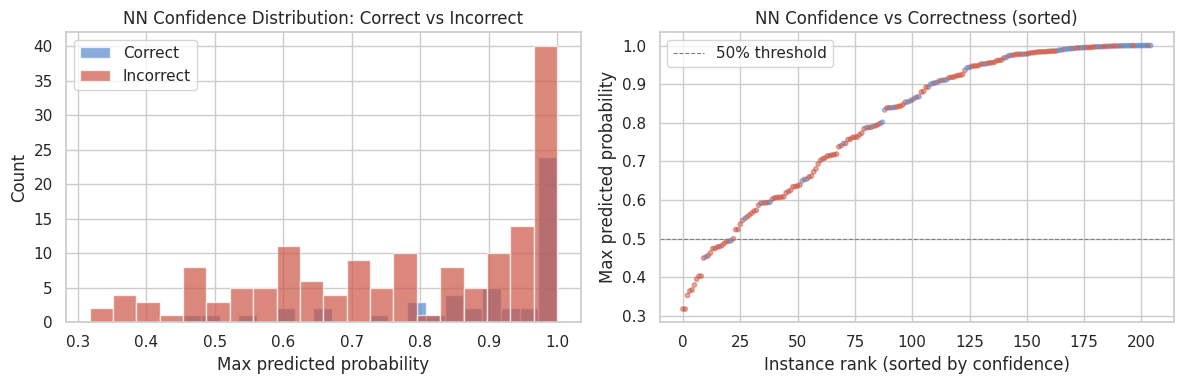

Mean confidence when correct:   0.888
Mean confidence when incorrect: 0.777
Fraction of wrong predictions > 0.5 confidence: 0.864


In [33]:
# NN max confidence distribution
nn_max_prob = y_prob.max(axis=1)
nn_correct  = (y_pred == y_test.values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of max prediction probability
axes[0].hist(nn_max_prob[nn_correct],  bins=20, alpha=0.7, label="Correct",   color="#5588cc")
axes[0].hist(nn_max_prob[~nn_correct], bins=20, alpha=0.7, label="Incorrect", color="#cc5544")
axes[0].set_xlabel("Max predicted probability")
axes[0].set_ylabel("Count")
axes[0].set_title("NN Confidence Distribution: Correct vs Incorrect")
axes[0].legend()

# Scatter: confidence vs correctness
axes[1].scatter(range(len(nn_max_prob)), np.sort(nn_max_prob),
                c=["#5588cc" if c else "#cc5544" for c in nn_correct[np.argsort(nn_max_prob)]],
                s=10, alpha=0.5)
axes[1].set_xlabel("Instance rank (sorted by confidence)")
axes[1].set_ylabel("Max predicted probability")
axes[1].set_title("NN Confidence vs Correctness (sorted)")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="50% threshold")
axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Mean confidence when correct:   {nn_max_prob[nn_correct].mean():.3f}")
print(f"Mean confidence when incorrect: {nn_max_prob[~nn_correct].mean():.3f}")
print(f"Fraction of wrong predictions > 0.5 confidence: {(nn_max_prob[~nn_correct] > 0.5).mean():.3f}")

**Interpretation:** The NN shows reasonable calibration \u2014 correct predictions have higher mean confidence. However, a notable fraction of wrong predictions have >50% confidence, indicating overconfidence. The secondary-type confusion cases tend to have lower confidence (probability split between type1 and type2), while completely wrong predictions sometimes exhibit high confidence \u2014 pointing to regions of feature space where the model has learned incorrect patterns due to class imbalance.

## 3.5 Class Imbalance Analysis

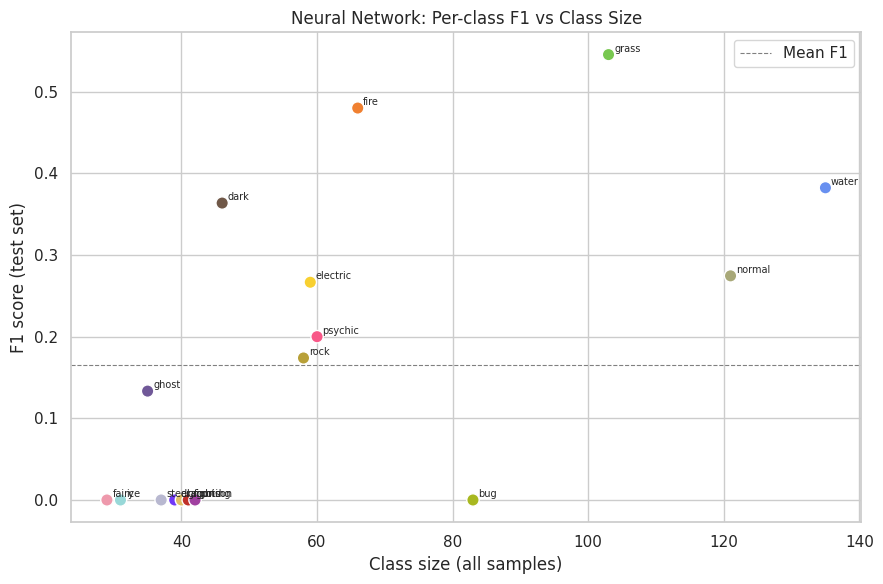

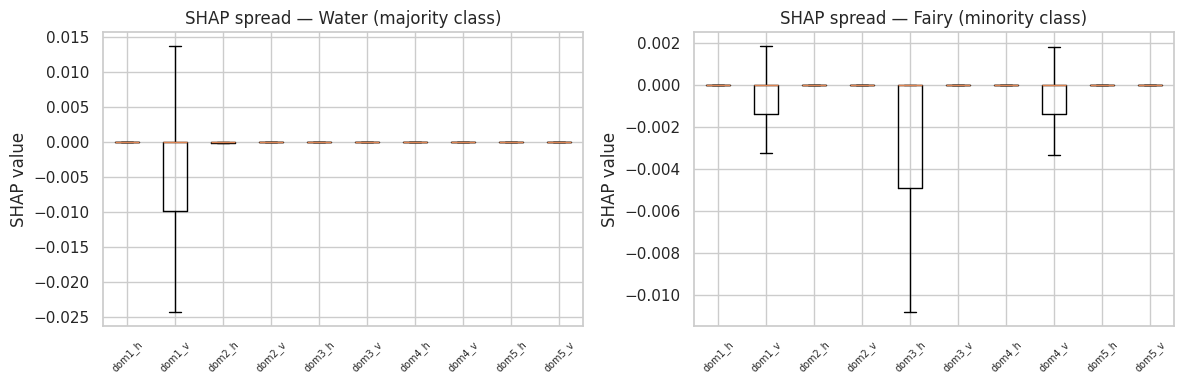

Water SHAP std: 0.0309
Fairy SHAP std: 0.0095


In [34]:
from sklearn.metrics import f1_score

# Per-class F1 for NN vs class size
class_counts = df["type1"].value_counts()
f1_per_class_nn = {}
for cls_int in sorted(int_to_type.keys()):
    type_name = int_to_type[cls_int]
    if type_name not in class_counts.index: continue
    f1 = f1_score(y_test == cls_int, y_pred == cls_int, zero_division=0)
    f1_per_class_nn[type_name] = {"f1": f1, "count": class_counts[type_name]}

f1_df = pd.DataFrame(f1_per_class_nn).T.astype(float).sort_values("count")
fig, ax = plt.subplots(figsize=(9, 6))
colors = [common.TYPE_COLORS.get(t, "#888") for t in f1_df.index]
ax.scatter(f1_df["count"], f1_df["f1"], c=colors, s=80, zorder=3, edgecolors="white")
for type_name, row_data in f1_df.iterrows():
    ax.annotate(type_name, (row_data["count"], row_data["f1"]),
                xytext=(4, 2), textcoords="offset points", fontsize=7)
ax.set_xlabel("Class size (all samples)")
ax.set_ylabel("F1 score (test set)")
ax.set_title("Neural Network: Per-class F1 vs Class Size")
ax.axhline(f1_df["f1"].mean(), color="gray", linestyle="--", linewidth=0.8, label="Mean F1")
ax.legend(); plt.tight_layout(); plt.show()

# SHAP value spread: minority (Fairy) vs majority (Water)
# shap_values_nn shape: (n_shap_samples, n_features, n_classes) — use 3rd axis for class
majority_cls = type_to_int.get("water", 17)
minority_cls = type_to_int.get("fairy", 4)
majority_pos = list(mlp_final.classes_).index(majority_cls)
minority_pos = list(mlp_final.classes_).index(minority_cls)

sv_majority = shap_values_nn[:, :, majority_pos]   # (n_shap_samples, n_features)
sv_minority = shap_values_nn[:, :, minority_pos]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([sv_majority[:, j] for j in range(0, 20, 2)],
                labels=feature_cols[0:20:2], showfliers=False)
axes[0].set_title("SHAP spread — Water (majority class)")
axes[0].tick_params(axis="x", rotation=45, labelsize=7)
axes[0].set_ylabel("SHAP value")

axes[1].boxplot([sv_minority[:, j] for j in range(0, 20, 2)],
                labels=feature_cols[0:20:2], showfliers=False)
axes[1].set_title("SHAP spread — Fairy (minority class)")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].set_ylabel("SHAP value")

plt.tight_layout(); plt.show()
print(f"Water SHAP std: {np.std(sv_majority):.4f}")
print(f"Fairy SHAP std: {np.std(sv_minority):.4f}")

**Interpretation:** There is a clear positive correlation between class size and F1 score \u2014 Water (134 samples) achieves high F1 while Fairy (29 samples) and Ice (31 samples) score poorly. The SHAP spread for Fairy is narrower and more variable than for Water, indicating the model has learned less stable, less generalizable patterns for minority types. For XAI purposes, explanations for minority-class predictions should be treated with greater skepticism \u2014 they are based on fewer training examples and the model's internal representations for these classes are less refined. This is a direct consequence of training on imbalanced data without resampling.

# 4. Generative AI Section

All prompts used during this project are documented below for reproducibility.